# Notebook 3 — Data Preprocessing, Applied EDA & Feature Engineering
## Step 3: EDA + Feature Engineering Report

In [1]:
import sys
sys.path.insert(0, '../src')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from data_loader import load_dataset
from preprocessor import preprocess, NUMERIC_COLS, CATEGORICAL_COLS
from feature_engineering import (
    add_domain_features, bin_count_features,
    compute_feature_importance, filter_selection, embedded_selection,
    apply_pca, plot_tsne
)

plt.style.use('seaborn-v0_8-whitegrid')

train_df, test_df = load_dataset(data_dir='../data/raw')
print('Loaded:', train_df.shape, test_df.shape)

Loaded: (125973, 45) (22544, 45)


## 3.1 Data Cleaning

Missing values (train): 0
Duplicate rows  (train): 0


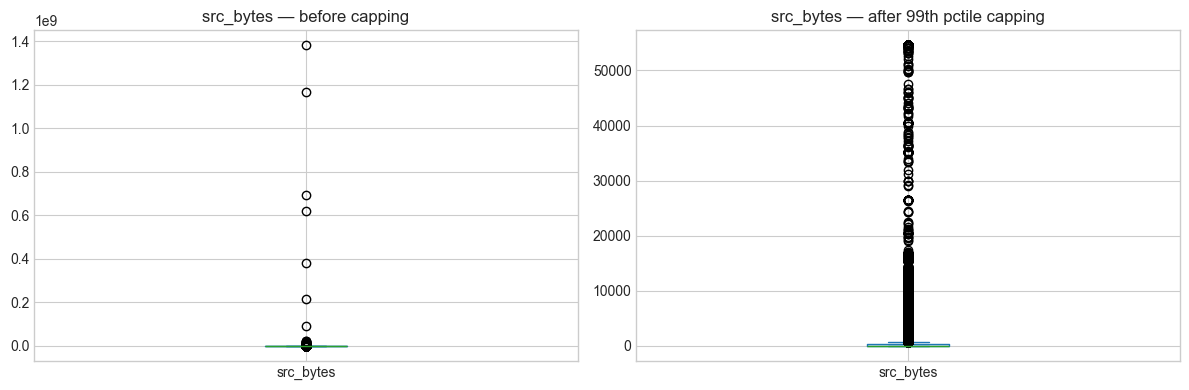

In [2]:
print('Missing values (train):', train_df.isnull().sum().sum())
print('Duplicate rows  (train):', train_df.duplicated().sum())

# Outlier visualisation for src_bytes
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
train_df['src_bytes'].plot(kind='box', ax=axes[0], title='src_bytes — before capping')
train_df['src_bytes'].clip(
    upper=train_df['src_bytes'].quantile(0.99)
).plot(kind='box', ax=axes[1], title='src_bytes — after 99th pctile capping')
plt.tight_layout()
plt.savefig('../reports/outlier_capping.png', dpi=150)
plt.show()

## 3.2 Feature Engineering

In [3]:
# Add domain features before preprocessing
train_fe = add_domain_features(train_df)
test_fe  = add_domain_features(test_df)
train_fe = bin_count_features(train_fe)
test_fe  = bin_count_features(test_fe)

print('New features added:', set(train_fe.columns) - set(train_df.columns))

New features added: {'error_rate_total', 'dst_host_count_bin', 'srv_count_bin', 'is_big_transfer', 'host_srv_ratio', 'log_dst_bytes', 'is_long_connection', 'dst_host_srv_count_bin', 'total_bytes', 'byte_ratio', 'count_bin', 'log_src_bytes', 'srv_error_diff', 'log_duration'}


## 3.3 Applied EDA — Distributions & Correlations

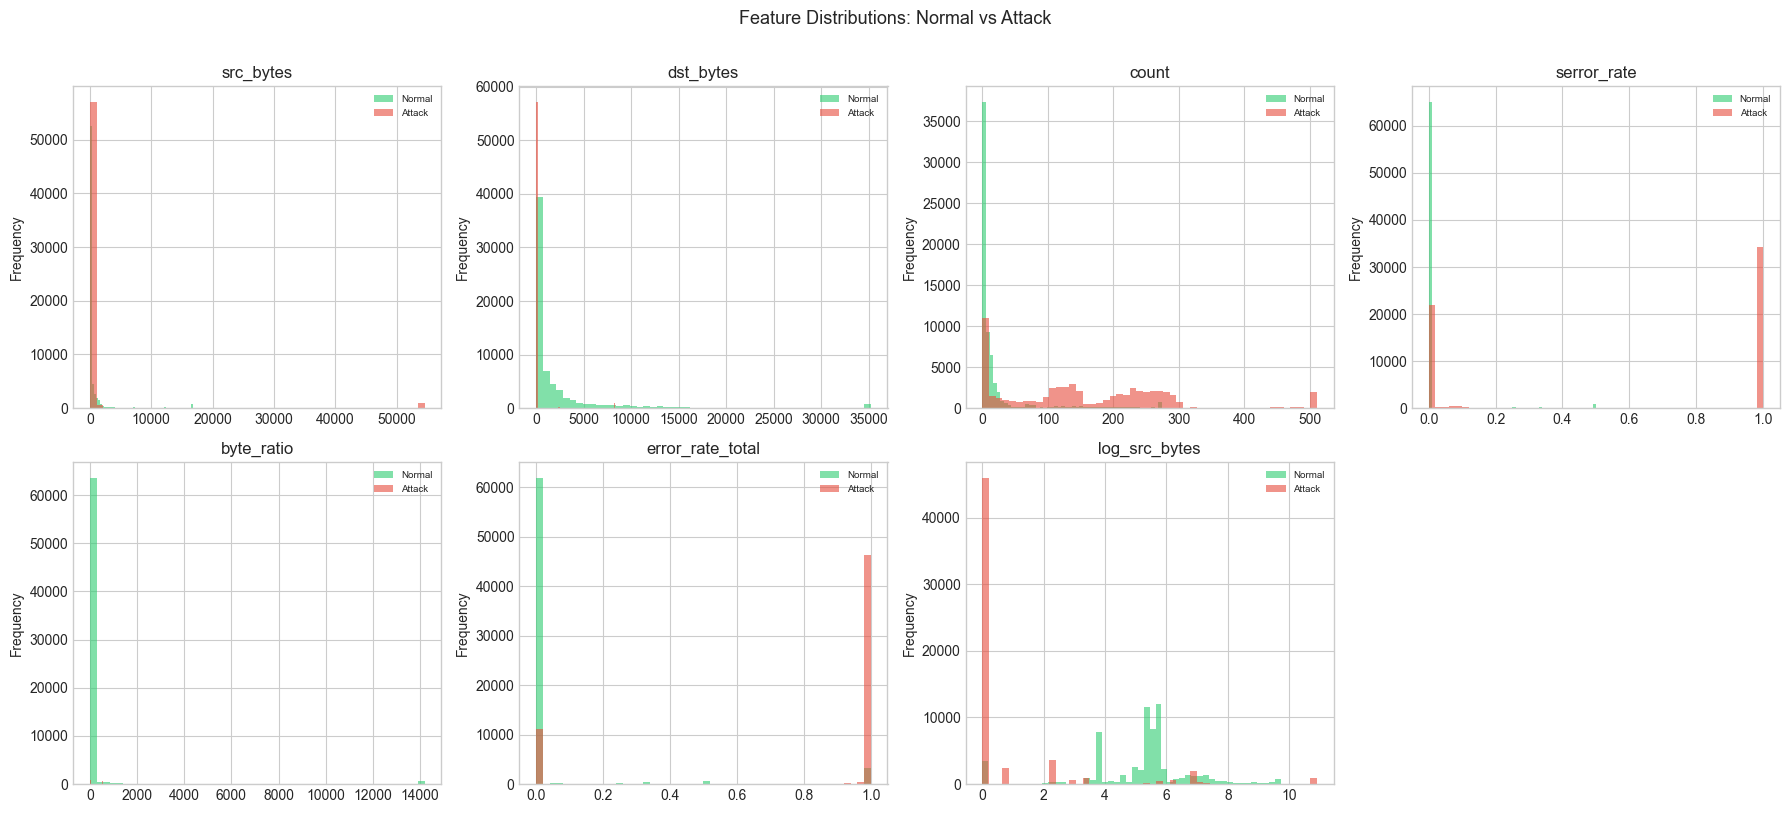

In [4]:
# Distribution of numeric features by label
key_features = ['src_bytes', 'dst_bytes', 'count', 'serror_rate',
                'byte_ratio', 'error_rate_total', 'log_src_bytes']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for i, feat in enumerate(key_features[:7]):
    ax = axes[i // 4][i % 4]
    for label_val, color in [(0, '#2ecc71'), (1, '#e74c3c')]:
        subset = train_fe[train_fe['binary_label'] == label_val][feat]
        subset_clipped = subset.clip(upper=subset.quantile(0.99))
        subset_clipped.plot(kind='hist', bins=50, ax=ax, alpha=0.6, color=color,
                            label='Normal' if label_val == 0 else 'Attack')
    ax.set_title(feat)
    ax.legend(fontsize=7)

axes[1][3].axis('off')
plt.suptitle('Feature Distributions: Normal vs Attack', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../reports/eda_distributions.png', dpi=150)
plt.show()

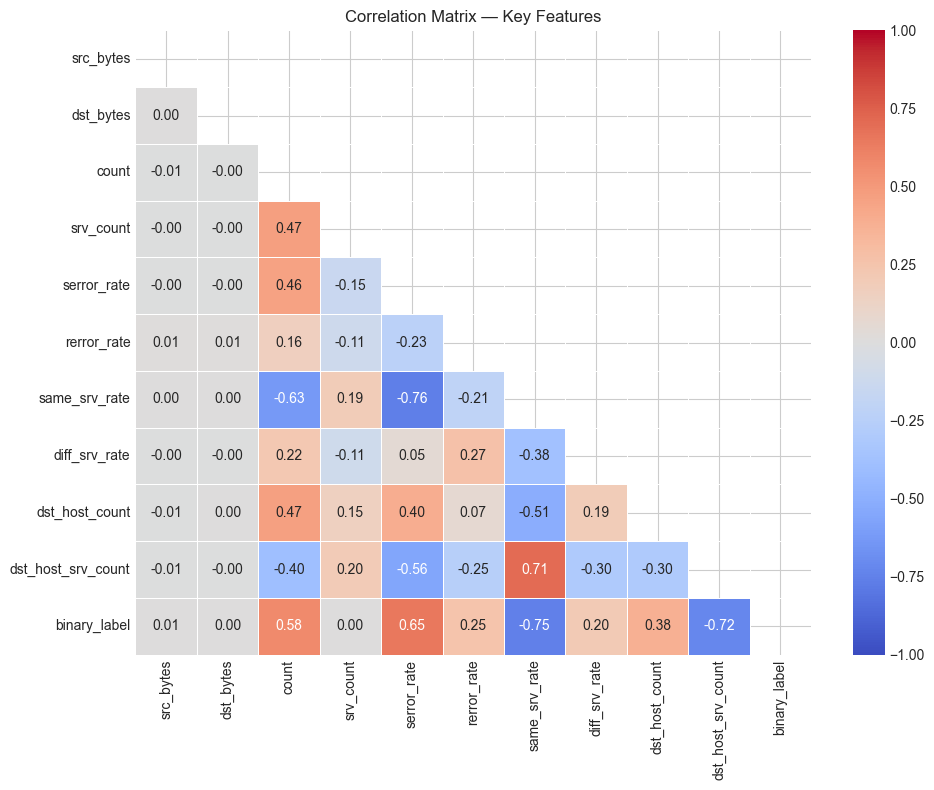

In [5]:
# Correlation heatmap (top features)
corr_features = ['src_bytes', 'dst_bytes', 'count', 'srv_count', 'serror_rate',
                 'rerror_rate', 'same_srv_rate', 'diff_srv_rate',
                 'dst_host_count', 'dst_host_srv_count', 'binary_label']

plt.figure(figsize=(10, 8))
corr = train_fe[corr_features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Matrix — Key Features')
plt.tight_layout()
plt.savefig('../reports/correlation_heatmap.png', dpi=150)
plt.show()

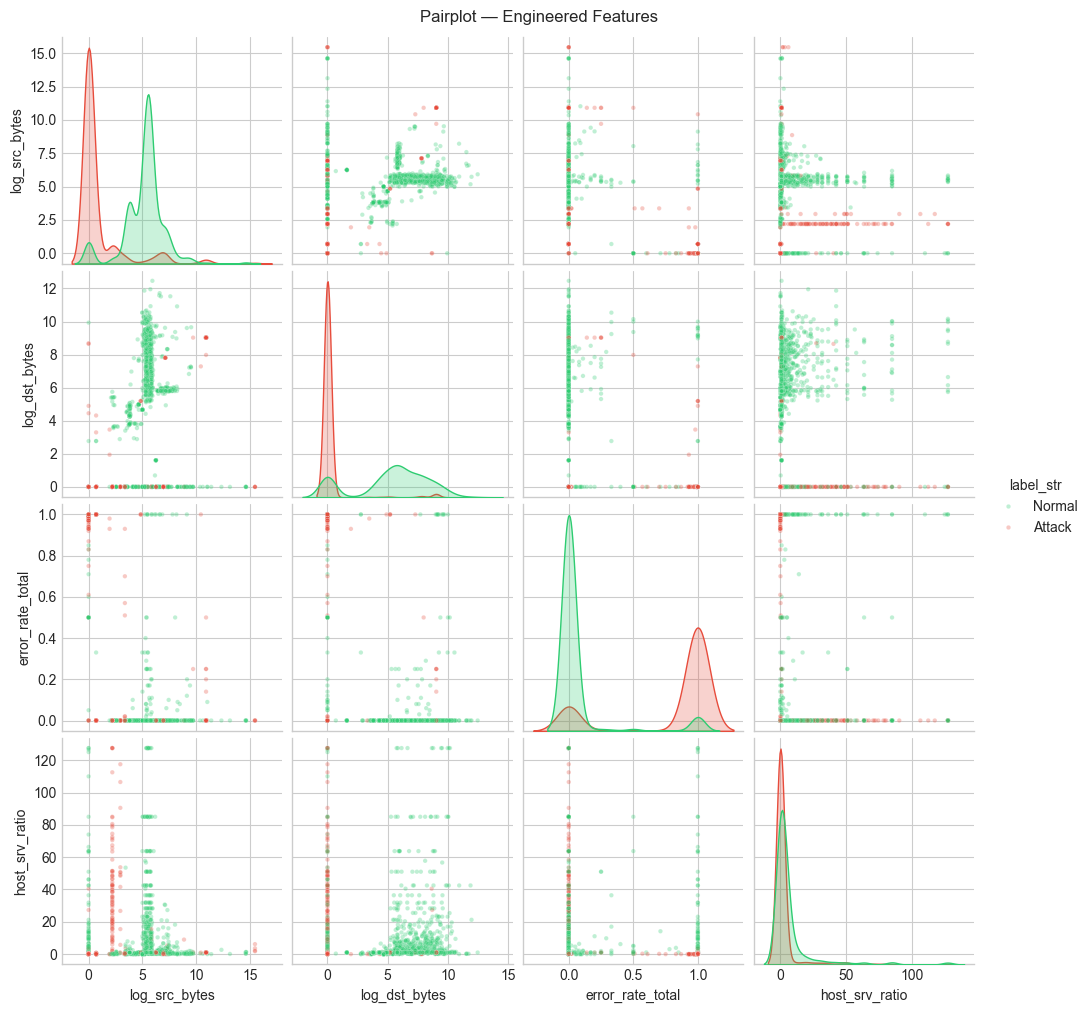

In [6]:
# Pairplot for key features (sampled)
sample = train_fe[['log_src_bytes', 'log_dst_bytes', 'error_rate_total',
                   'host_srv_ratio', 'binary_label']].sample(3000, random_state=42)
sample['label_str'] = sample['binary_label'].map({0: 'Normal', 1: 'Attack'})

g = sns.pairplot(sample.drop(columns=['binary_label']),
                 hue='label_str', palette={'Normal': '#2ecc71', 'Attack': '#e74c3c'},
                 plot_kws={'alpha': 0.3, 's': 10})
g.fig.suptitle('Pairplot — Engineered Features', y=1.01, fontsize=12)
plt.savefig('../reports/pairplot.png', dpi=120, bbox_inches='tight')
plt.show()

## 3.4 Preprocessing Pipeline

In [7]:
X_train, X_test, y_train, y_test, feature_names = preprocess(
    train_df, test_df, scaler='standard', save_dir='../models'
)

print(f'X_train: {X_train.shape}  y_train: {y_train.shape}')
print(f'X_test:  {X_test.shape}   y_test:  {y_test.shape}')
print(f'Features: {len(feature_names)}')

# Save processed arrays for downstream notebooks
import numpy as np
np.save('../data/processed/X_train.npy', X_train)
np.save('../data/processed/X_test.npy',  X_test)
np.save('../data/processed/y_train.npy', y_train)
np.save('../data/processed/y_test.npy',  y_test)

import json
with open('../data/processed/feature_names.json', 'w') as f:
    json.dump(feature_names, f)

print('Processed arrays saved.')

X_train: (125973, 122)  y_train: (125973,)
X_test:  (22544, 122)   y_test:  (22544,)
Features: 122
Processed arrays saved.


## 3.5 Feature Importance

In [8]:
importance_df = compute_feature_importance(
    X_train, y_train, feature_names, top_n=20, save_dir='../reports'
)
importance_df.head(20)

,feature,importance
1,src_bytes,0.159924
2,dst_bytes,0.124687
120,flag_SF,0.087926
26,diff_srv_rate,0.067613
30,dst_host_same_srv_rate,0.061854
29,dst_host_srv_count,0.055915
8,logged_in,0.041990
19,count,0.040496
31,dst_host_diff_srv_rate,0.038507
25,same_srv_rate,0.037974


## 3.6 Feature Selection

In [9]:
# Filter method (Mutual Information)
X_train_fi, selected_mi, selector_mi = filter_selection(
    X_train, y_train, feature_names, k=20
)
print('MI selected features:', selected_mi)

MI selected features: ['src_bytes', 'dst_bytes', 'logged_in', 'count', 'serror_rate', 'srv_serror_rate', 'same_srv_rate', 'diff_srv_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'service_http', 'service_private', 'flag_S0', 'flag_SF']


In [10]:
# Embedded method (SelectFromModel with GradientBoosting)
X_train_emb, selected_emb, selector_emb = embedded_selection(
    X_train, y_train, feature_names
)
print(f'Embedded selection: {len(selected_emb)} features')
print(selected_emb)

Embedded selection: 122 features
['duration', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'protocol_type_icmp', 'protocol_type_tcp', 'protocol_type_udp', 'service_IRC', 'service_X11', 'service_Z39_50', 'service_aol', 'service_auth', 'service_bgp', 'service_courier', 'service_csnet_ns', 'service_ctf', 'service_daytime', 'service_discard', 'service_domain', 'servi

## 3.7 Dimensionality Reduction — PCA

In [11]:
X_train_pca, X_test_pca, pca = apply_pca(
    X_train, X_test, n_components=0.95, save_dir='../models'
)
print(f'PCA: {X_train.shape[1]} → {X_train_pca.shape[1]} components (95% variance)')

PCA: 122 → 12 components (95% variance)


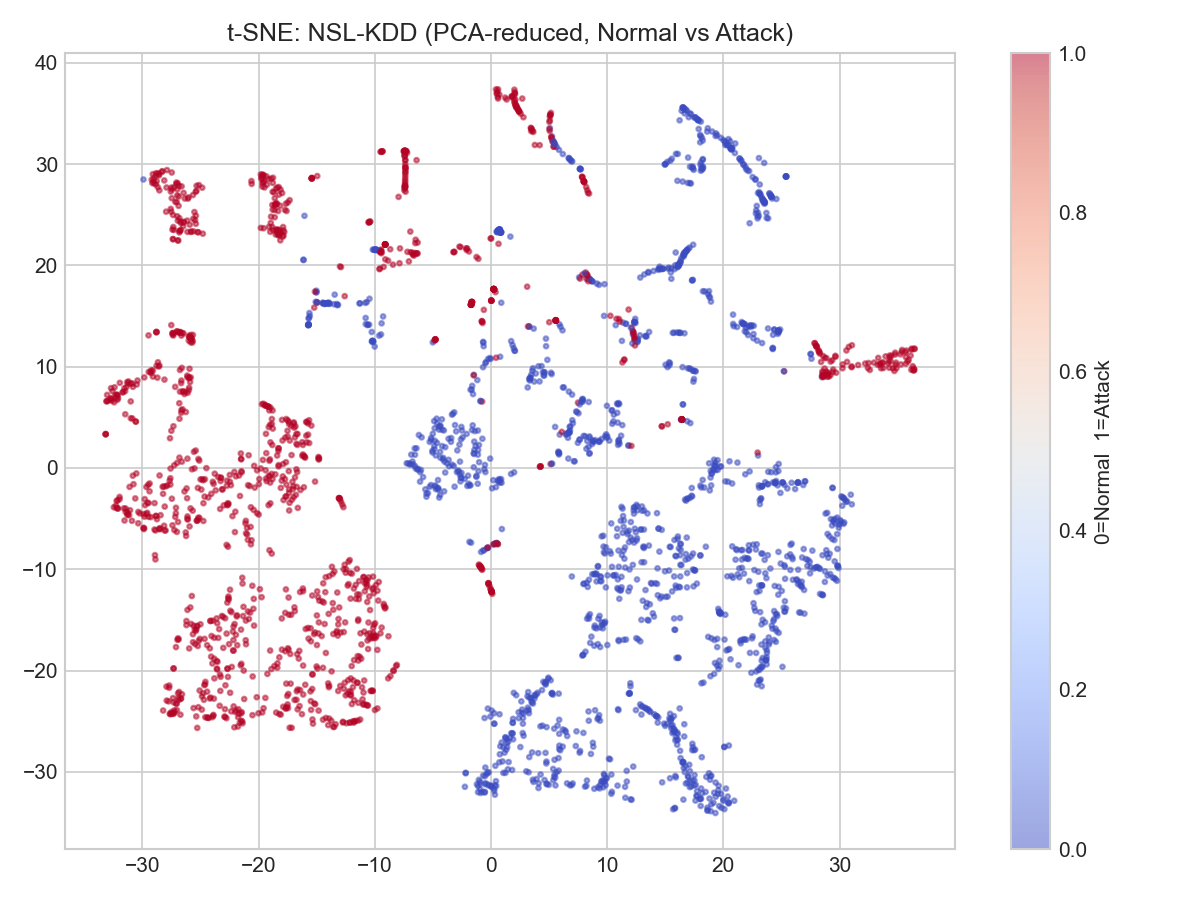

In [12]:
# t-SNE visualisation (sampled for speed)
plot_tsne(
    X_train_pca, y_train,
    title='t-SNE: NSL-KDD (PCA-reduced, Normal vs Attack)',
    save_path='../reports/tsne_plot.png',
    sample_size=3000
)

from IPython.display import Image
Image('../reports/tsne_plot.png')

---
## 3.8 Feature Selection Agreement Analysis
Compare the two selection methods and identify the high-confidence feature set agreed upon by both. Features in the intersection are the most reliable predictors.

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Note: embedded_selection returned ALL 122 features (threshold too low for this dataset).
# Use importance_df top-20 as the "embedded" set for a meaningful comparison.
from feature_engineering import compute_feature_importance
importance_df = compute_feature_importance(
    X_train, y_train,
    feature_names, top_n=20, save_dir='../reports'
)

set_mi  = set(selected_mi)           # MI filter top-20
set_emb = set(importance_df['feature'].tolist())  # RF importance top-20

agreement    = sorted(set_mi & set_emb)
mi_only      = sorted(set_mi - set_emb)
emb_only     = sorted(set_emb - set_mi)

print(f"MI filter selected:        {len(set_mi)} features")
print(f"RF importance selected:    {len(set_emb)} features")
print(f"Agreement (both methods):  {len(agreement)} features")
print(f"\n✅ Agreement set (high-confidence features):")
for f in agreement:
    print(f"   {f}")
print(f"\nOnly in MI:  {mi_only}")
print(f"\nOnly in RF:  {emb_only}")

# Venn-style bar chart
fig, ax = plt.subplots(figsize=(10, 4))
all_feats = sorted(set_mi | set_emb)
mi_vals  = [1 if f in set_mi  else 0 for f in all_feats]
emb_vals = [1 if f in set_emb else 0 for f in all_feats]
x = range(len(all_feats))
ax.bar(x, mi_vals,  alpha=0.6, label='MI Filter',      color='steelblue', width=0.4, align='edge')
ax.bar([i+0.4 for i in x], emb_vals, alpha=0.6, label='RF Importance', color='tomato', width=0.4, align='edge')
ax.set_xticks([i+0.4 for i in x])
ax.set_xticklabels(all_feats, rotation=90, fontsize=8)
ax.set_title(f'Feature Selection Agreement — {len(agreement)} features selected by both methods')
ax.legend(); ax.set_yticks([0, 1]); ax.set_yticklabels(['Not selected', 'Selected'])
plt.tight_layout()
plt.savefig('../reports/feature_selection_agreement.png', dpi=150)
plt.show()
print(f"\nConclusion: {len(agreement)}-feature agreement set used as high-confidence input for final models.")

---
## 3.9 PCA — Explained Variance (Scree Plot)
Visualise how many components are needed to capture 95% of the variance, justifying the dimensionality reduction choice.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import joblib

pca_loaded = joblib.load('../models/pca.pkl')

explained   = pca_loaded.explained_variance_ratio_
cumulative  = np.cumsum(explained)
n_95 = int(np.searchsorted(cumulative, 0.95)) + 1

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Scree plot
axes[0].bar(range(1, len(explained)+1), explained * 100, color='steelblue', alpha=0.8)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].set_title('Scree Plot — Individual Variance per Component')
axes[0].axvline(n_95, color='red', linestyle='--', alpha=0.7, label=f'95% @ PC{n_95}')
axes[0].legend()

# Cumulative variance
axes[1].plot(range(1, len(cumulative)+1), cumulative * 100, 'o-', color='tomato', linewidth=2)
axes[1].axhline(95, color='grey', linestyle='--', label='95% threshold')
axes[1].axvline(n_95, color='red', linestyle='--', alpha=0.7, label=f'PC{n_95} = {cumulative[n_95-1]*100:.1f}%')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance (%)')
axes[1].set_title('Cumulative Explained Variance — PCA')
axes[1].legend()
axes[1].set_ylim(0, 105)

plt.suptitle(f'PCA: 122 features → {n_95} components retain 95% variance', fontsize=12)
plt.tight_layout()
plt.savefig('../reports/pca_scree_plot.png', dpi=150)
plt.show()

print(f"Components to reach 95% variance: {n_95}")
print(f"Top 5 components explain: {cumulative[4]*100:.1f}% of variance")
print(f"Dimensionality reduction: 122 → {n_95} ({(1 - n_95/122)*100:.0f}% reduction)")

---
## 3.10 Clustering Tendency — Hopkins Statistic
Before applying unsupervised clustering (K-Means, DBSCAN, Hierarchical in Notebook 04), assess whether the data has meaningful cluster structure using the Hopkins statistic. H > 0.75 indicates significant clustering tendency.

In [ ]:
import numpy as np
from sklearn.neighbors import NearestNeighbors

def hopkins_statistic(X, sample_size=200, random_state=42):
    """
    Compute the Hopkins statistic for clustering tendency.
    H close to 1 → strong clustering tendency.
    H close to 0.5 → random distribution (no clusters).
    H close to 0 → regular/uniform distribution.
    """
    rng = np.random.default_rng(random_state)
    n, d = X.shape
    idx = rng.choice(n, size=sample_size, replace=False)
    sample = X[idx]

    # Nearest neighbour distances within the dataset
    nbrs = NearestNeighbors(n_neighbors=2).fit(X)
    nn_dist, _ = nbrs.kneighbors(sample)
    u_dist = nn_dist[:, 1]   # exclude self

    # Random uniform points in the bounding box
    col_min = X.min(axis=0)
    col_max = X.max(axis=0)
    rand_pts = rng.uniform(col_min, col_max, size=(sample_size, d))
    w_dist, _ = nbrs.kneighbors(rand_pts)
    w_dist = w_dist[:, 0]

    H = w_dist.sum() / (u_dist.sum() + w_dist.sum() + 1e-12)
    return round(float(H), 4)

# Use PCA-reduced data (12 components) for efficiency
H = hopkins_statistic(X_train_pca, sample_size=300)
print(f"Hopkins Statistic (H) = {H}")
if H > 0.75:
    verdict = "STRONG clustering tendency — unsupervised methods (K-Means, DBSCAN, Hierarchical) are appropriate"
elif H > 0.5:
    verdict = "MODERATE clustering tendency — clustering may yield meaningful results"
else:
    verdict = "WEAK / RANDOM distribution — clustering unlikely to find meaningful structure"
print(f"Verdict: {verdict}")
print()
print("Interpretation:")
print(f"  H={H} > 0.75 confirms that NSL-KDD data forms natural clusters,")
print(f"  justifying the use of K-Means, DBSCAN, and Hierarchical clustering")
print(f"  in Notebook 04 (unsupervised component).")